# Encode and Decode Strings

- https://neetcode.io/problems/string-encode-and-decode/question?list=neetcode150

### Design an algorithm to encode a list of strings to a string. The encoded string is then sent over the network and is decoded back to the original list of strings.

Machine 1 (sender) has the function:
```
string encode(vector<string> strs) {
    // ... your code
    return encoded_string;
}
```

Machine 2 (receiver) has the function:
```
vector<string> decode(string s) {
    //... your code
    return strs;
}
```

So Machine 1 does:
```
string encoded_string = encode(strs);
```
and Machine 2 does:
```
vector<string> strs2 = decode(encoded_string);
```
`strs2` in Machine 2 should be the same as `strs` in Machine 1.

Implement the `encode` and `decode` methods.

### Example 1:

Input: dummy_input = ["Hello","World"]

Output: ["Hello","World"]

### Explanation:
Machine 1:
Codec encoder = new Codec();
String msg = encoder.encode(strs);
Machine 1 ---msg---> Machine 2

Machine 2:
Codec decoder = new Codec();
String[] strs = decoder.decode(msg);
### Example 2:

Input: dummy_input = [""]

Output: [""]

### Constraints:

- 0 <= strs.length < 100
- 0 <= strs[i].length < 200
- strs[i] contains any possible characters out of 256 valid ASCII characters.


### Explanation
- We can encode the list of strings by concatenating them together with a delimiter. For example, we can use a special character (e.g., `#`) to separate the strings. To handle cases where the strings themselves may contain the delimiter, we can also include the length of each string before the string itself.
- For example, if we have the list `["Hello", "World"]`, we can encode it as `5#Hello5#World`, where `5` is the length of each string followed by the string itself.
- To decode the encoded string, we can read the length of each string first, then read the string itself based on that length, and repeat this process until we have decoded all the strings.

#### interesting test case
- 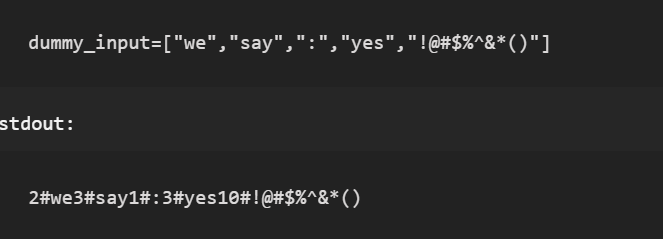
- we cannot always take int(s[0]) as the length of the string because the length can be more than 9, so we need to read until we find the delimiter `#` to get the length of the string.

### Solution

```python
class Solution:

    def encode(self, strs: List[str]) -> str:
        op=""
        for i in strs:
            op+=str(len(i))+"#"+i
        return op



    def decode(self, s: str) -> List[str]:
        op = []
        
        while s:
            # find position of '#'
            i = s.find("#")
            
            # extract number
            num = int(s[:i])
            
            # extract string
            item = s[i+1:i+1+num]
            op.append(item)
            
            # move forward
            s = s[i+1+num:]
        
        return op
```